**Objetivo**:

Analizar la rentabilidad de las estrategias de marketing de una empresa dedicada a la venta de boletos para eventos en línea, mediante el estudio de métricas clave de negocio como el costo de adquisición de clientes (CAC), el retorno de la inversión en marketing (ROMI) y el valor del tiempo de vida del cliente (LTV), con el fin de identificar los canales publicitarios más eficientes.

**Preguntas clave**
- ¿Cuál es el ingreso promedio que una empresa obtiene por sus clientes? (LTV)
- ¿Cuál es el costo de adquisición de clientes por cada una de las publicidades? (CAC)
- ¿Cuál fue la rentabilidad de las campañas publicitaria para la empresa? (ROMI)

#**1.- Procesamiento y Limpieza de Datos**

In [135]:
#Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [136]:
#Cargar datasets
visits = pd.read_csv("/content/visits_log_us.csv")
orders = pd.read_csv("/content/orders_log_us.csv")
costs = pd.read_csv("/content/costs_us.csv")

In [137]:
#Observar la informacion del dataset "visits"
print(visits.info())
visits.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None


,Device,End Ts,Source Id,Start Ts,Uid
68856,desktop,2018-03-23 21:58:00,3,2018-03-23 21:55:00,3760596920058588138
23291,touch,2017-10-07 14:55:00,2,2017-10-07 14:48:00,10399141731106471898
62504,desktop,2017-10-03 10:40:00,3,2017-10-03 10:39:00,6443359011093388991
211007,touch,2017-11-28 11:17:00,1,2017-11-28 10:59:00,17369153666139763736
5132,desktop,2017-12-12 18:12:00,3,2017-12-12 18:10:00,2135971817684829469
334208,touch,2017-10-19 10:05:00,4,2017-10-19 10:04:00,12020713517415974806
352436,desktop,2018-04-17 22:43:00,4,2018-04-17 22:43:00,3813419770123602177
304422,touch,2018-01-17 23:27:00,4,2018-01-17 23:27:00,9307789164582639863
119737,touch,2017-11-10 09:18:00,3,2017-11-10 09:06:00,15104255408914582498
259900,touch,2018-01-02 12:09:00,3,2018-01-02 11:51:00,6398838184497805023


In [138]:
#Observar la informaciòn del dataset orders
print(orders.info())
orders.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None


,Buy Ts,Revenue,Uid
50221,2018-05-31 16:12:00,0.30,6197148363928929573
47347,2018-05-15 15:40:00,4.03,6863852234865527896
31298,2018-01-27 11:25:00,3.67,17853150615152412286
48346,2018-05-21 20:59:00,0.30,1545874204002665954
44238,2018-04-16 10:26:00,6.72,5455361078626688710
39315,2018-03-10 16:13:00,4.89,4148298663822971078
46058,2018-04-30 22:05:00,1.10,7004261792713452790
21718,2017-12-03 20:26:00,4.89,1563959594219043635
18687,2017-11-21 13:18:00,9.17,5979868369688278750
12468,2017-10-12 22:46:00,0.61,5604705867129065507


In [139]:
#Observar la informacion del dataset costs
print(costs.info())
costs.sample(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None


,source_id,dt,costs
603,2,2018-01-27,129.01
796,3,2017-08-10,246.74
1403,4,2018-04-13,487.00
1580,5,2017-10-07,209.63
1999,9,2017-12-01,26.85
4,1,2017-06-05,57.08
1112,4,2017-06-24,143.20
1038,3,2018-04-11,322.04
652,2,2018-03-17,99.27
1958,9,2017-10-21,7.91


**Observaciones**

- Cambiar las columnas tipo snakecase de los tres datasets
- En el dataset de **visits** cambiar el tipo de datos de la columna **End Ts** y **Start Ts** a tipo date y la columna **uid** a object
- En el dataset de **orders** cambiar el tipo de datos de la columna **Buy_Ts** y la columna **uid** a object.
- En el dataset de **costs** cambiar el tipo de dato de la columna **dt** a date


# Cambio de las columnas a tipo snakecase

In [140]:
# Cambiar el tipo las columnas tipo snackecase del dataset visits y orders
visits.columns = [x.lower().replace(" ","_") for x in visits.columns]
orders.columns = [x.lower().replace(" ","_") for x in orders.columns]
print(visits.columns)
print(orders.columns)

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')
Index(['buy_ts', 'revenue', 'uid'], dtype='object')


# Cambio de tipo de datos de los datasets

In [141]:
visits["end_ts"] = pd.to_datetime(visits["end_ts"], format="%Y-%m-%d %H:%M:%S")
visits["start_ts"] = pd.to_datetime(visits["start_ts"], format="%Y-%m-%d %H:%M:%S")
visits["uid"] = visits["uid"].astype(str)
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 13.7+ MB


In [142]:
#Cambiar el tip de datos del dataset orders
orders["buy_ts"] = pd.to_datetime(orders["buy_ts"], format="%Y-%m-%d %H:%M:%S")
orders["uid"] = orders["uid"].astype(str)
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.2+ MB


In [143]:
#Cambiar el tipo de datos del dataset costs
costs["dt"] = pd.to_datetime(costs["dt"])
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


#Observar los datos nulos y duplicados

In [144]:
#Observar los datos nulos y duplicados de cada dataset
def nulos_duplicados(df):
  print("Datos nulos")
  print(df.isna().sum() )
  print("-"*50)
  print("Datos duplicados")
  print(df.duplicated().sum())


In [145]:
#LLamar la funcion nulos_duplicados
nulos_duplicados(costs)

Datos nulos
source_id    0
dt           0
costs        0
dtype: int64
--------------------------------------------------
Datos duplicados
0


**Observaciones**
- No se encontraron datos nulos ni duplicados en ningun dataset.

# Análisis estadístico

**DataFrame Visits**

In [146]:
#Observar el dataset visits
visits

,device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168
...,...,...,...,...,...
359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586
359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294
359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485


**1.- ¿Cuántos usarios usan la plataforma por día, semana y mes?**

In [175]:
#Agregar columnas al dataset visits por dia, semana y mes
visits["day"] = visits["start_ts"].dt.date
visits["week"] = visits["start_ts"].dt.isocalendar().week
visits["month"] = visits["start_ts"].dt.month

# Calcular las metricas (DAU, WAU, MAU) agrupar los datos por la columna de timepo y utilizar funciòn de agregaciòn nunique para la columna "uid".
dau = visits.groupby("day")["uid"].nunique().mean()
wau = visits.groupby("week")["uid"].nunique().mean()
mau = visits.groupby("month")["uid"].nunique().mean()

print(f"DAU - Número promedio de usuarios diarios: {dau:.2f}")
print(f"WAU - Número promedio de usuarios semanales: {wau:.2f}")
print(f"MAU - Número promedio de usuarios mensuales: {mau:.2f}")


DAU - Número promedio de usuarios diarios: 907.99
WAU - Número promedio de usuarios semanales: 5825.29
MAU - Número promedio de usuarios mensuales: 23228.42


**2.- ¿Cuántas sesiones hay por día?**

In [148]:
#Sesiones para cada dìa
print("Sesiones para cada día especifico ")
#Agrupamos los datos con la variable tiempo que queremos estimar y utilizamos la funcion de agregacion count() para contabilizar las SESIONES.
sesiones_per_day = visits.groupby("day")["uid"].size().reset_index(name="sesiones")

print(sesiones_per_day)
print("\n" + "="*50 + "\n")

#Promedio de sesiones por dia
sesiones_per_day_mean = sesiones_per_day["sesiones"].mean()
print(f"El nùmero promedio de sesiones por día es de: {sesiones_per_day_mean:.2f}")

Sesiones para cada día especifico 
            day  sesiones
0    2017-06-01       664
1    2017-06-02       658
2    2017-06-03       477
3    2017-06-04       510
4    2017-06-05       893
..          ...       ...
359  2018-05-27       672
360  2018-05-28      1156
361  2018-05-29      1035
362  2018-05-30      1410
363  2018-05-31      2256

[364 rows x 2 columns]


El nùmero promedio de sesiones por día es de: 987.36


**3.- ¿Cuál es la duración de cada sesión?**


In [149]:
#Crear una columna y restar la columna del tiempo final y la columna cuando empezo la sesion.
visits["duration_per_session"] = (visits["end_ts"] - visits["start_ts"]).dt.total_seconds() / 60

#Contar el tiempo promedio que dura una sesion
duration_per_session_mean = visits["duration_per_session"].mean().astype(int)
print(f"La duracion promedio de cada sesion es de {duration_per_session_mean} minutos")


La duracion promedio de cada sesion es de 10 minutos


In [150]:
#Observar las estadisticas de la variable "duration_per_session"
visits["duration_per_session"].describe()

,duration_per_session
count,359400.000000
mean,10.717095
std,16.618796
min,-46.000000
25%,2.000000
50%,5.000000
75%,14.000000
max,711.000000


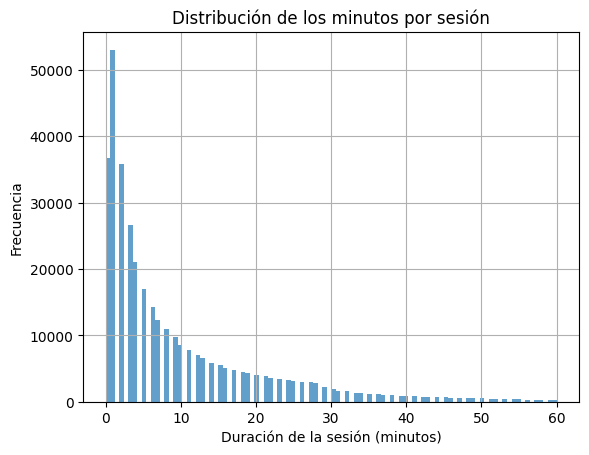

In [151]:
#Gráfico de histograma para observar la distribución de tiempo por sesión.
visits["duration_per_session"].hist(bins=100, alpha=0.7, range=(0,60))
plt.title("Distribución de los minutos por sesión")
plt.xlabel("Duración de la sesión (minutos)")
plt.ylabel("Frecuencia")
plt.show()

**Observaciones**:
- El histograma nos muesta una distribución con sesgo  a la derecha, La mayor concentración de datos se encuentra entre 1 y 5 minutos, por lo que la mayoría de los usuarios permanecen poco tiempo en el sitio.

**4.- ¿Con qué frecuencia los usuarios regresan?**


In [152]:
#Crear otro DataFrame de visits ordenado con sort_values, ordena la columna de "UID" Y "START_TS"
visits_sorted = visits.sort_values(by=["uid", "start_ts"])

#Crear columnas "start_day" y "end_day" para ocupar las propiedades temporales por el dìa
visits_sorted["start_day"] = pd.to_datetime(visits_sorted["start_ts"]).dt.date
visits_sorted["end_day"] =  pd.to_datetime(visits_sorted["end_ts"]).dt.date

#Crear columna donde almacene el tiempo de retorno
visits_sorted["prev_visit"] = visits_sorted.groupby("uid")["start_day"].shift(1)
visits_sorted["days_since_last"] = pd.to_timedelta(visits_sorted["start_day"] - visits_sorted["prev_visit"])

#Observar el promedio de dìas en que regresan los usuarios a la pagina web
days_mean = visits_sorted["days_since_last"].dt.days.mean()
print(f"El nùmero de dìas promedio que los usuarios regresan a la pàgina web es de: {days_mean:.1f}")
#display(visits_sorted [["uid", "start_day", "prev_visit", "days_since_last"]].head(10))
print(("\n" + "="*100 + "\n"))

#Observa el tiempo màs frecuente en el que regresan los usuarios
days_mode = visits_sorted["days_since_last"].dt.days.mode()
print(f"El timpo màs frecuente que regresan los usuarios es el mismo dìa con un valor de {days_mode[0]}")

print(("\n" + "="*100 + "\n"))
#Estadisticas de la variable de "days_since_last"
print("Estadisticas del tiempo en dìas que regresan los usuarios a la pàgina web")
print(visits_sorted["days_since_last"].dt.days.describe())

El nùmero de dìas promedio que los usuarios regresan a la pàgina web es de: 28.1


El timpo màs frecuente que regresan los usuarios es el mismo dìa con un valor de 0.0


Estadisticas del tiempo en dìas que regresan los usuarios a la pàgina web
count    131231.000000
mean         28.106857
std          49.730245
min           0.000000
25%           1.000000
50%           5.000000
75%          32.000000
max         363.000000
Name: days_since_last, dtype: float64


**DataFrame Orders (ventas)**

**1.- ¿Cuándo empieza la gente a comprar?**

In [153]:
#Observar el dataframes de orders
orders

,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624
50411,2018-05-31 23:50:00,5.80,11369640365507475976
50412,2018-05-31 23:54:00,0.30,1786462140797698849
50413,2018-05-31 23:56:00,3.67,3993697860786194247


In [154]:
#PASO 1
#Identificar la primera visita(registro) de cada usuario en la web(tiempo del primer momento)
primera_visita = visits.groupby("uid")["start_ts"].min().reset_index()
primera_visita.columns = ["uid", "primera_visita"]

#PASO 2
#Identificar la primera compra de cada usuario en la web
primera_compra = orders.groupby("uid")["buy_ts"].min().reset_index()
primera_compra.columns = ["uid", "primera_compra"]

#PASO 3
#Unir los DataFrames de la primera visita con la primera compra
primera_visita_compra = primera_visita.merge(primera_compra, on="uid") #Conversion data
#print("Datos de la primera visita y primera compra")
#print(primera_visita_compra)
#print("\n" + "="*50 + "\n")

#PASO 4
#Calcular el tiempo que transcurrio entre la primera visita y la primera compra.
primera_visita_compra["time_conversion"] = (primera_visita_compra["primera_compra"] - primera_visita_compra["primera_visita"]).dt.days

#Calcular el tiempo promedio en que los usuarios empeizan a comprar
time_conversion_mean = primera_visita_compra["time_conversion"].mean().astype(int)
print(f"El tiempo promedio en que los usuarios empiezan a comprar es a los {time_conversion_mean} dìas.")

print(("\n" + "="*100 + "\n"))


print("Tiempo hasta la conversión (días) para algunos usuarios:")
display(primera_visita_compra[['uid', 'primera_compra', 'primera_visita', 'time_conversion']].head(10))

El tiempo promedio en que los usuarios empiezan a comprar es a los 16 dìas.


Tiempo hasta la conversión (días) para algunos usuarios:


,uid,primera_compra,primera_visita,time_conversion
0,10000837700716403746,2017-06-21 16:12:00,2017-06-08 10:12:00,13
1,10000997030965831953,2018-01-19 12:28:00,2018-01-19 11:16:00,0
2,10001199569370567060,2017-11-25 17:29:00,2017-11-25 17:26:00,0
3,10002243978166172255,2017-10-15 17:20:00,2017-10-15 17:18:00,0
4,10003351403065971701,2017-11-20 13:18:00,2017-11-20 13:17:00,0
5,10003425910527970929,2018-03-25 19:26:00,2018-03-25 19:01:00,0
6,10003843789561818935,2017-12-12 20:54:00,2017-09-25 23:05:00,77
7,10003858247064282365,2017-10-31 21:54:00,2017-08-22 23:05:00,69
8,10003922165532733227,2017-11-16 09:43:00,2017-11-16 09:42:00,0
9,10004355444061692288,2017-12-03 12:44:00,2017-12-03 12:43:00,0


In [155]:
#Observar las estadisticas de time_conversion
primera_visita_compra["time_conversion"].describe()

,time_conversion
count,36523.000000
mean,16.729869
std,46.959088
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,363.000000


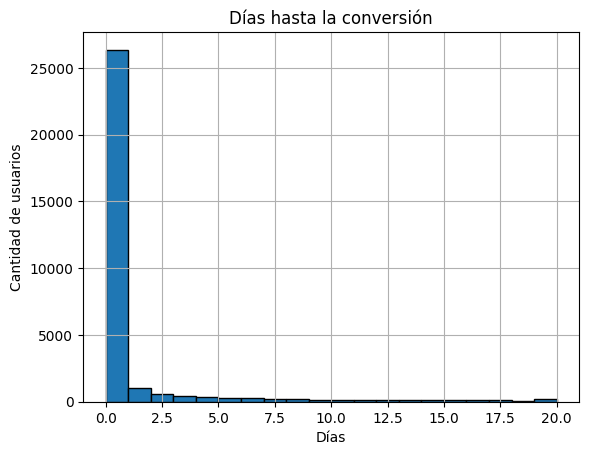

In [156]:
#Gráfico de histograma para ver los dìas hasta la conversion.
primera_visita_compra["time_conversion"].hist(bins=20, edgecolor='black', range=(0,20))
plt.ylabel('Cantidad de usuarios')
plt.title('Días hasta la conversión')
plt.xlabel('Días')
plt.show()

**Observacions**
- El histograma y la mediana muestran que el 50% de los usuarios compran el mismo día que hacen la visita a la plataforma, se observa un promedio alto posibles usuarios que regresaron a la pagina y se tardaron en comprar.


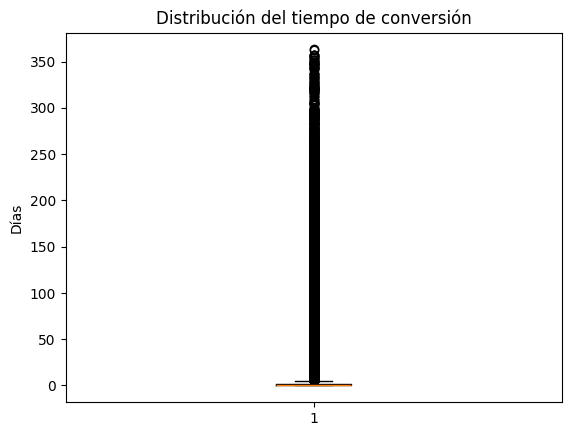

In [157]:
#Observar si hay valores atipicos
plt.boxplot(primera_visita_compra["time_conversion"])
plt.title("Distribución del tiempo de conversión")
plt.ylabel("Días")

plt.show()

**Observaciones**

- Se encontraron bastantes valores atipicos en el tiempo de conversión pueden tarda hasta más de un año en que un usuario haga su primera compra.

**2.- ¿Cuántos pedidos hacen durante un período de tiempo dado?**

In [158]:
#Crear una columana con el tiempo(por dìa, semana, mes),  para estimar los pedidos por dia.
orders["buy_day"] =  orders["buy_ts"].dt.date
orders["buy_week"] = orders["buy_ts"].dt.isocalendar().week
orders["buy_month"] = orders["buy_ts"].dt.month


#Contabiliar los dìas en que se repiten, para encontrar el nùmero de pedidos por dìa, semana, mes, year con el mètodo size()
orders_per_day = orders.groupby("buy_day").size()
orders_per_week = orders.groupby("buy_week").size()
orders_per_month = orders.groupby("buy_month").size()


#Saber cual es el promedio de pedidos por dìa, semana, mes y año.
orders_per_day_mean = orders_per_day.mean().astype(int)
print(f"EL nùmero promedio de pedidos por dìa es de {orders_per_day_mean}")
orders_per_week_mean = orders_per_week.mean().astype(int)
print(f"El nùmero promedio de pedidos por semana es de {orders_per_week_mean}")
orders_per_month_mean =orders_per_month.mean().astype(int)
print(f"El nùmero promedio de pedidos por mes es de {orders_per_month_mean}")

EL nùmero promedio de pedidos por dìa es de 138
El nùmero promedio de pedidos por semana es de 969
El nùmero promedio de pedidos por mes es de 4201


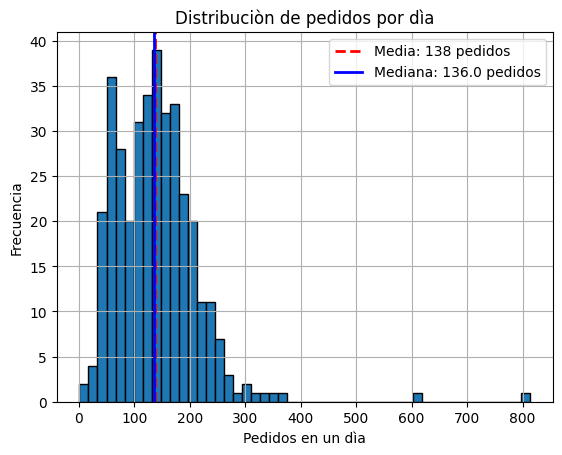

In [159]:
#Gràfico de Histograma
orders_per_day.hist(bins=50,edgecolor="black")
# Calcular estadísticas
media = orders_per_day.mean().astype(int)
mediana = orders_per_day.median()
# Agregar líneas
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:} pedidos')
plt.axvline(mediana, color='blue', linestyle='-', linewidth=2, label=f'Mediana: {mediana:} pedidos')
plt.title("Distribuciòn de pedidos por dìa")
plt.xlabel("Pedidos en un dìa")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


**Observaciones**
- El 50% del número de pedidos promedio en un día es 138 pedidos. Hay algunos días excepcionales con muchísimos pedidos entre 600 y 800.

**3.-¿Cuál es el tamaño de compra?**

In [160]:
#Obtener el promedio de las compras
revenue_mean = orders["revenue"].mean().round().astype(int)
print(f"Un usuario en promedio compra ${revenue_mean} dólares en la plataforma")


Un usuario en promedio compra $5 dólares en la plataforma


**4.-¿Cuál es el ingreso promedio que una empresa obtiene por los clientes? (LTV)**




In [161]:
#LIFETIME VALUE por usuario (¿Cuánto dinero traen los usurios a las empresas)
ltv_per_user = orders.groupby("uid")["revenue"].sum()
ltv_per_user_mean = ltv_per_user.mean().astype(int)
print(f"Cada usuario en promedio trae a la empresa ${ltv_per_user_mean} dolares por dia")

Cada usuario en promedio trae a la empresa $6 dolares por dia


In [162]:
orders

,buy_ts,revenue,uid,buy_day,buy_week,buy_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,22,6
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,22,6
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,22,6
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,22,6
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,22,6
...,...,...,...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05-31,22,5
50411,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05-31,22,5
50412,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05-31,22,5
50413,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31,22,5


**Observaciones**
- El tiempo promedio en que los usuarios empiezan a comprar es a los 16 días.

- EL número promedio de pedidos por día es de 138

- El tamaño promedio de compra es de $5 dolares

- El ingreso promedio que obtiene  la empresa por usuario es $6 dolares

**DataFrame costs (marketing)**

In [163]:
costs

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08
...,...,...,...
2537,10,2018-05-27,9.92
2538,10,2018-05-28,21.26
2539,10,2018-05-29,11.32
2540,10,2018-05-30,33.15


**1.-  ¿Cuánto dinero se gastó?  (Total / por fuente de adquisición a lo largo del tiempo)**

In [164]:
#Realizar el calculo del GASTO TOTAL EN PUBLICIDAD
gasto_total = costs["costs"].sum()
print(f"El gasto total en publicidad es de: ${gasto_total}")

print(("\n" + "="*100 + "\n"))


#Realizar el calculo del GASTO POR PUBLICIDAD (segementado por "source_id")
gasto_per_source = costs.groupby("source_id")["costs"].sum().astype(int).reset_index()
print("Gasto por cada publicidad")
print(gasto_per_source)

El gasto total en publicidad es de: $329131.62


Gasto por cada publicidad
   source_id   costs
0          1   20833
1          2   42806
2          3  141321
3          4   61073
4          5   51757
5          9    5517
6         10    5822


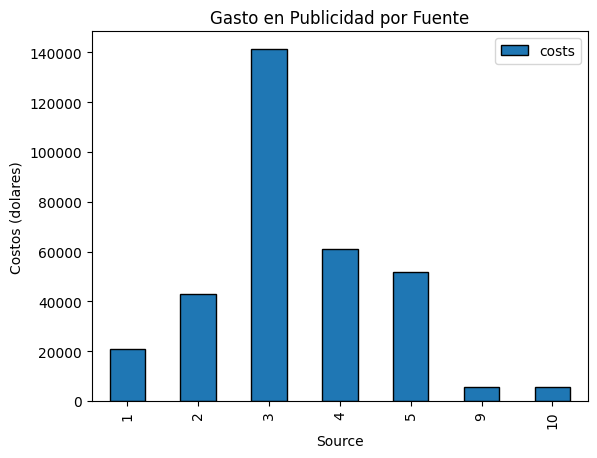

In [165]:
# Graficar gasto por fuente (barras)
gasto_per_source.plot(kind="bar", x="source_id", y="costs", edgecolor='black')
plt.title('Gasto en Publicidad por Fuente')
plt.xlabel('Source')
plt.ylabel('Costos (dolares)')
plt.show()

- El gasto total por publicidad es de $329,131 usd

- La campaña publicitara que màs costo fue la nùmero tres con $141,321 usd

**2. ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?**

In [166]:
#Realizar el calculo del  Costo de Adquisición por Clientes (CAC) de cada una de las fuentes
#PASO 1
#Ordenar el DataFrame de visits y gruparlo por "uid" y "source_id"
user_source = visits.sort_values(by='start_ts').groupby('uid').first().reset_index()[['uid', 'source_id']]


#PASO 2
#Unir los datos #primera_visita_compra" con "user_source"
df_merge_user_id = user_source.merge(primera_visita_compra, on="uid")

#PASO 3
#Calcular cuántos clientes unicos vinieron de cada fuente y ademas realizaron una compra
usuarios_per_source = df_merge_user_id.groupby("source_id")["uid"].nunique().reset_index()
print("El nùmero de usurios unicos adquiridos por fuente")
print(usuarios_per_source)
print(("\n" + "="*100 + "\n"))

#PASO 4
#Unir los datos de "gasto_per_source" y "usuarios_per_source"
df_merge_cac = gasto_per_source.merge(usuarios_per_source, on="source_id")

#PASO 5
#CALCULAR EL CAC
df_merge_cac["cac"] = df_merge_cac["costs"] / df_merge_cac["uid"]

print(f"El Costo de Adquisicon por cliente (CAC)")
df_merge_cac

El nùmero de usurios unicos adquiridos por fuente
   source_id    uid
0          1   2899
1          2   3506
2          3  10473
3          4  10296
4          5   6931
5          7      1
6          9   1088
7         10   1329


El Costo de Adquisicon por cliente (CAC)


,source_id,costs,uid,cac
0,1,20833,2899,7.186271
1,2,42806,3506,12.209355
2,3,141321,10473,13.493841
3,4,61073,10296,5.931721
4,5,51757,6931,7.467465
5,9,5517,1088,5.070772
6,10,5822,1329,4.380737


In [167]:
cac_mean = df_merge_cac["cac"].mean()
print(f"El promedio de Costo de Adquision de cada cliente por publicidad es de {cac_mean.round(0)}")

El promedio de Costo de Adquision de cada cliente por publicidad es de 8.0


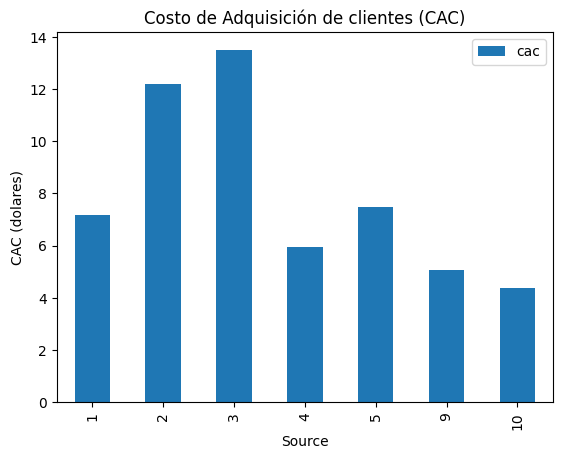

In [168]:
#Gràfico de barras para ver el Costo de Adquisiciòn por Client (CAC)
df_merge_cac.plot(kind="bar", x="source_id", y="cac")
plt.xlabel("Source")
plt.ylabel("CAC (dolares)")
plt.title("Costo de Adquisición de clientes (CAC)")
plt.show()

**Observaciones:**

-En la publicidad 3 a la empresa le cuesta $13.50 dolares para a traer a un nuevo cliente.

-El Costo de Adquisiciòn por cliente màs bajo fue la publicidad 10 con un costo de $4.38 dolares.

-El promedio de Costo de Adquision de cada cliente por publicidad es de 8.0



**3. ¿Cuán rentables eran las inversiones? (ROMI)**

In [169]:
# Asociar órdenes con la fuente de adquisición (utilizando la fuente del primer registro)
orders_with_source = orders.merge(user_source, on='uid', how='left')
orders_with_source.head()

,buy_ts,revenue,uid,buy_day,buy_week,buy_month,source_id
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,22,6,1
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,22,6,2
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,22,6,2
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,22,6,2
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,22,6,3


In [170]:
#Agrupar ingresos por fuente
revenue_per_source = orders_with_source.groupby('source_id')['revenue'].sum().reset_index()
print(revenue_per_source)
print(gasto_per_source)

   source_id   revenue
0          1  31090.55
1          2  46923.61
2          3  54511.24
3          4  56696.83
4          5  52624.02
5          7      1.22
6          9   5759.40
7         10   4450.33
   source_id   costs
0          1   20833
1          2   42806
2          3  141321
3          4   61073
4          5   51757
5          9    5517
6         10    5822


In [171]:
#Unir DataFrames
df_merge_revenue_gasto = revenue_per_source.merge(gasto_per_source, on="source_id")
df_merge_revenue_gasto


,source_id,revenue,costs
0,1,31090.55,20833
1,2,46923.61,42806
2,3,54511.24,141321
3,4,56696.83,61073
4,5,52624.02,51757
5,9,5759.40,5517
6,10,4450.33,5822


In [172]:
#Calcular el ROMI
df_merge_revenue_gasto["romi"] = (df_merge_revenue_gasto["revenue"] - df_merge_revenue_gasto["costs"]) / df_merge_revenue_gasto["costs"]
print("Return On Marketing Investment (ROMI)")
df_merge_revenue_gasto

Return On Marketing Investment (ROMI)


,source_id,revenue,costs,romi
0,1,31090.55,20833,0.492370
1,2,46923.61,42806,0.096192
2,3,54511.24,141321,-0.614274
3,4,56696.83,61073,-0.071655
4,5,52624.02,51757,0.016752
5,9,5759.40,5517,0.043937
6,10,4450.33,5822,-0.235601


In [173]:
romi_mean = df_merge_revenue_gasto["romi"].mean()
print(f"El promedio de dinero obtenido por cada publicidad lanzada es de {romi_mean}")

El promedio de dinero obtenido por cada publicidad lanzada es de -0.038896887570512594


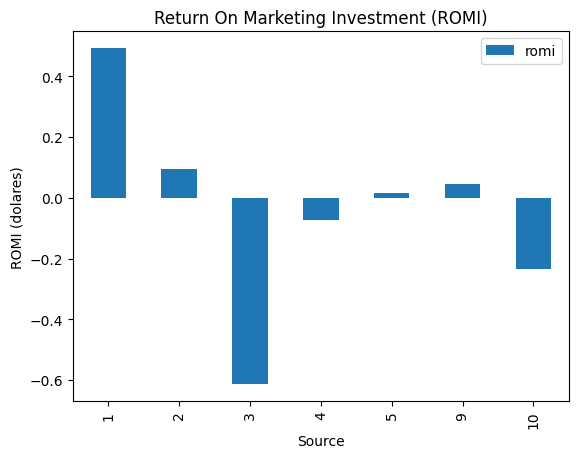

In [174]:
#Gràfico de barras para ver el Return On Marketng Investment (ROMI)
df_merge_revenue_gasto.plot(kind="bar", x="source_id", y="romi")
plt.xlabel("Source")
plt.ylabel("ROMI (dolares)")
plt.title("Return On Marketing Investment (ROMI)")
plt.show()

**Observaciones**

- En la fuente 1, por cada 1 dólar invertido en publicidad se gana $.50 centavos de dólar.

- En la fuente 2, por cada 1 dólar invertido se gana $0.09 centavos.

- En la fuente 3, por cada 1 dòlar invertido se pierde $0.61 centavos de dólar, hay una perdida significativa.



**Conclusiones**

-El número promedio de usuarios diarios es de 907.99 (DAU)

-El número promedio de usuarios semanales es de 5825.29 (WAU)

-El número promedio de usuarios mensuales es de 23228.42 (MAU)

-El número promedio de sesiones por día es de: 987.36

-El tiempo que un usuario pasa en la plataforma esta entre 1 y 5 minutos.

-El 50% de los usuarios compran el mismo día que hacen la visita a la plataforma.

-EL número promedio de pedidos por día es de 138.

-El número promedio de pedidos por semana es de 969.

-El número promedio de pedidos por mes es de 4201.

-Un usuario en promedio compra $5 dólares en la plataforma.

-Cada usuario en promedio trae a la empresa $6 dólares por día.

-El promedio de Costo de Adquisición de cada cliente por publicidad es de 8.0.

**Conclusiones generales**

-Los resultados indican que la empresa debe priorizar la inversión en las fuentes publicitarias que combinan una alta rentabilidad y un costo de adquisición eficiente, particularmente la fuente 1. Asimismo, se recomienda reducir la inversión en las fuentes con ROMI negativo y CAC elevado, como la fuente 3, y analizar la calidad de los clientes adquiridos en canales de bajo costo, pero baja rentabilidad.